C:\Users\user\AppData\Local\Temp\ipykernel_27960\1825039445.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_files/data_files/diabetic_data.csv", na_values="?")


Weight column removed.
Remaining records: 100114

pahse 2
Codes to be scraped: ['428', '414', '786', '410', '486', '427', '491', '715', '682', '434', '780', '996', '276', '38', '250.8', '599', '584', 'V57', '250.6', '518']
428 Heart failure
414 Other forms of chronic ischemic heart disease
786 Symptoms involving respiratory system and other chest symptoms
410 Acute myocardial infarction
486 Pneumonia, organism unspecified
427 Cardiac dysrhythmias
491 Chronic bronchitis
715 Osteoarthrosis and allied disorders
682 Other cellulitis and abscess
434 Occlusion of cerebral arteries
780 General symptoms
996 Complications peculiar to certain specified procedures
276 Disorders of fluid, electrolyte, and acid-base balance
Description Not Found
250.8 Diabetes with other specified manifestations
599 Other disorders of urethra and urinary tract
584 Acute renal failure
V57 Care involving use of rehabilitation procedures
250.6 Diabetes with neurological manifestations
518 Other diseases of lung

pahse

C:\Users\user\AppData\Local\Temp\ipykernel_27960\1825039445.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='magma')


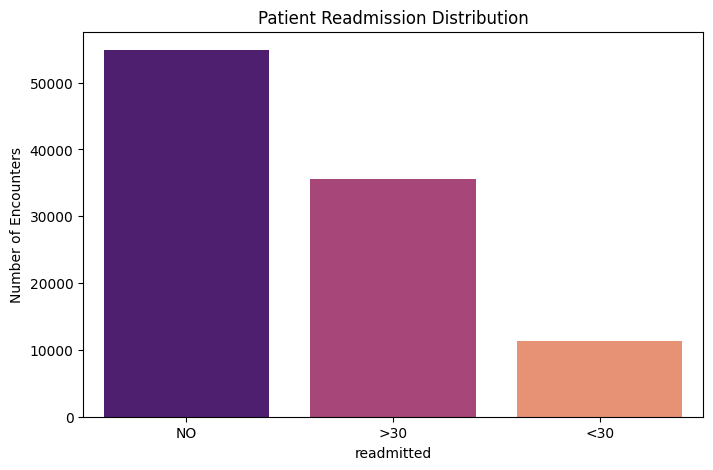


pahse 3.2


C:\Users\user\AppData\Local\Temp\ipykernel_27960\1825039445.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='age', order=age_order, palette='viridis')


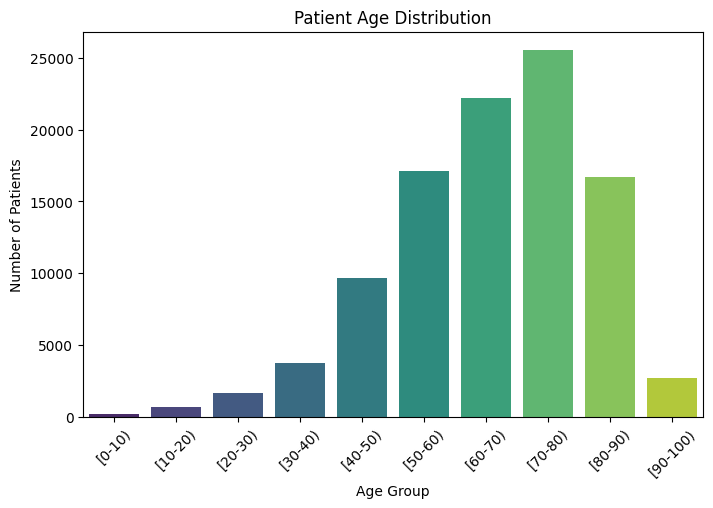

Age Distribution:
 age
[0-10)        160
[10-20)       690
[20-30)      1650
[30-40)      3765
[40-50)      9626
[50-60)     17102
[60-70)     22185
[70-80)     25562
[80-90)     16706
[90-100)     2668
Name: count, dtype: int64

Readmission Rates by Race and Gender:
 readmitted                   <30       >30        NO
race            gender                              
AfricanAmerican Female  0.112740  0.355737  0.531524
                Male    0.116216  0.344162  0.539622
Asian           Female  0.075949  0.281646  0.642405
                Male    0.129747  0.227848  0.642405
Caucasian       Female  0.116723  0.370850  0.512427
                Male    0.112695  0.353178  0.534127
Hispanic        Female  0.091743  0.324771  0.583486
                Male    0.119914  0.308351  0.571734
Other           Female  0.104336  0.303523  0.592141
                Male    0.091031  0.297189  0.611780


<Figure size 1000x500 with 0 Axes>

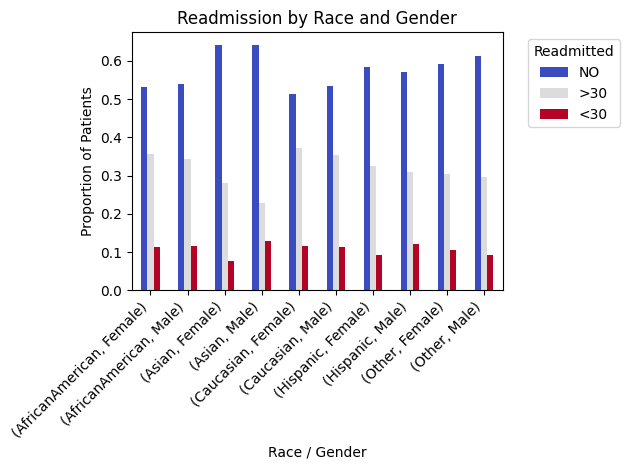


pahse 3.3

Readmission Rates: Insulin vs Others (%):
 readmitted              <30        >30         NO
medication_group                                 
Insulin           12.353558  36.673279  50.973163
Oral/No Med       10.188518  34.166667  55.644816

Readmission Rates: Dosage Change vs No Change (%):
 readmitted        <30        >30         NO
change                                     
Ch          11.967358  37.189673  50.842969
No          10.804718  34.046319  55.148963

pahse 3.4

pahse 3.4.a


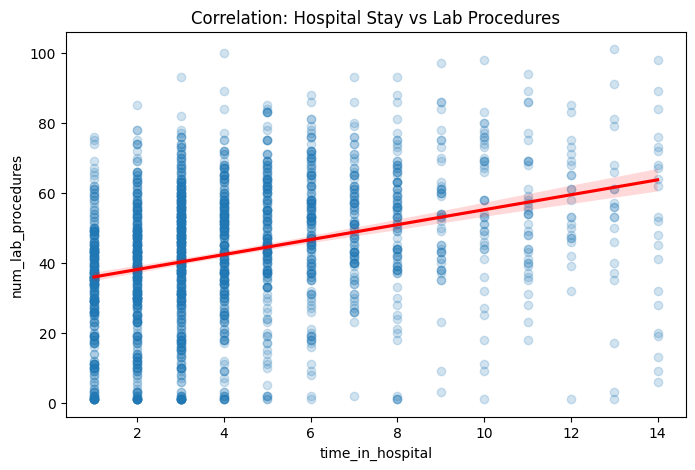


pahse 3.4.b


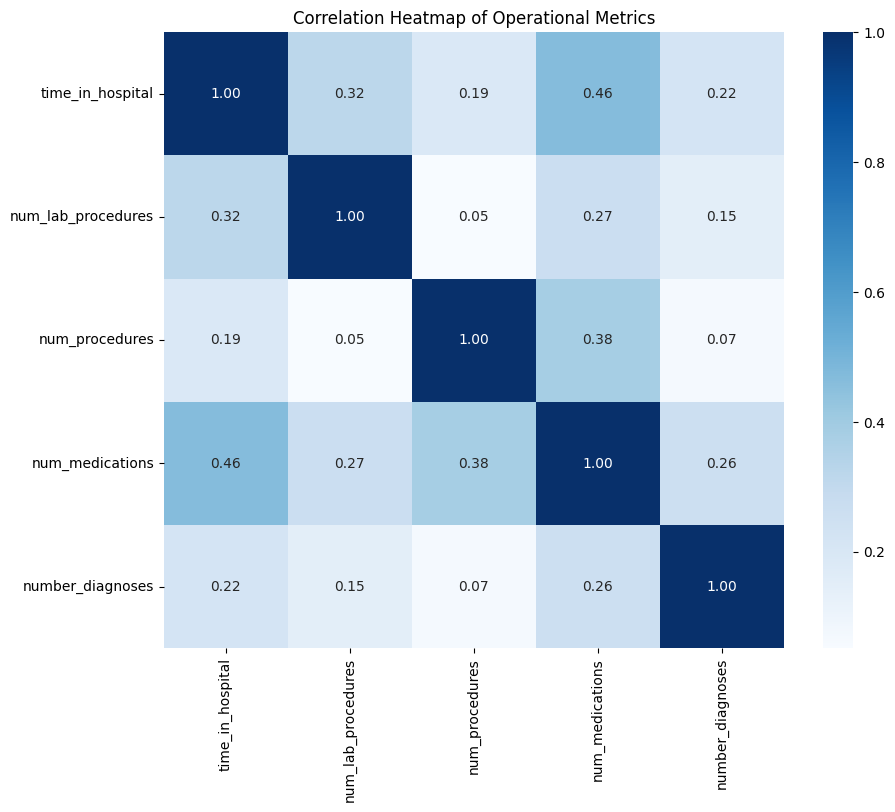


pahse 3.4.c


C:\Users\user\AppData\Local\Temp\ipykernel_27960\1825039445.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='readmitted', y='time_in_hospital', palette='Set2')


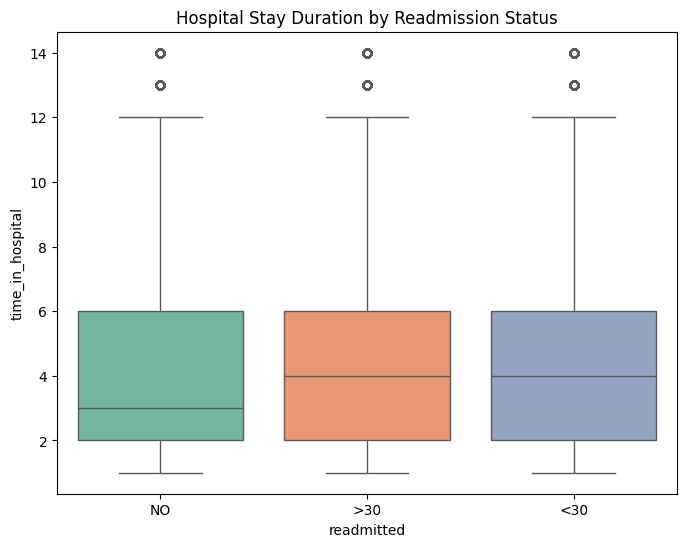


pahse 3.4.d

Return Rates: Home vs Skilled Nursing Facility (SNF) (%):
 readmitted              <30        >30         NO
discharge_target                                 
Home               9.300395  35.722350  54.977255
Other             14.306102  35.146185  50.547713
SNF               14.662462  35.230042  50.107496

pahse 4


C:\Users\user\AppData\Local\Temp\ipykernel_27960\1825039445.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk_Category', y='readmit_30d', data=df_cleaned,


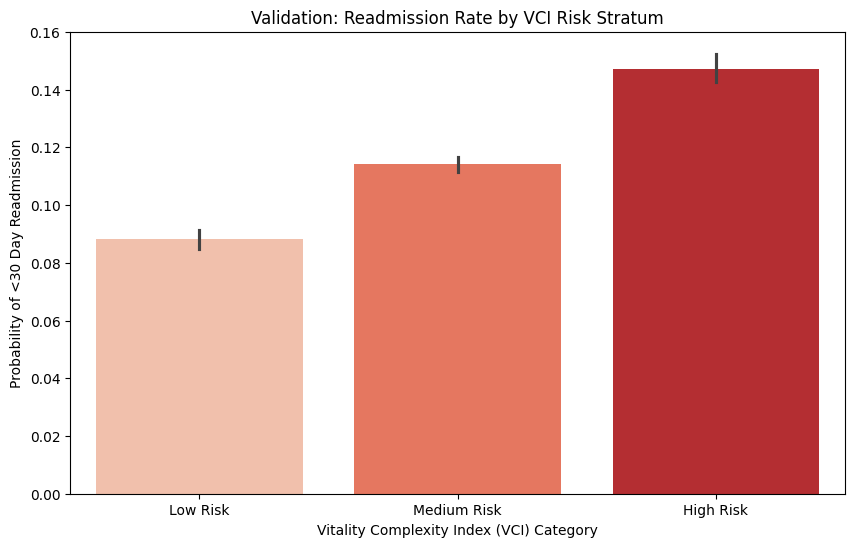


--- Clinical Risk Summary ---
Risk_Category
High Risk      14.727364
Low Risk        8.807516
Medium Risk    11.414182
Name: readmit_30d, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Specify that the 'data_files' folder is inside
df = pd.read_csv("data_files/data_files/diabetic_data.csv", na_values="?")

# To see if it loaded correctly (check the number of null values)
# print(df.isnull().sum())

# get data
# df.head(10)
# df.info()

# # check missing values percentage
# df.isna().mean() * 100

# # remove weight column
# df.drop(columns=["weight"], inplace=True) 
# print("Weight column removed.")

# #  remove expired patients
# expired_ids = [11, 19, 20]
# df = df[~df["discharge_disposition_id"].isin(expired_ids)]
# print(f"Remaining records: {len(df)}")

# # remove duplicate rows
# df = df.drop_duplicates()

# # clean invalid gender values
# df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)



def cleanData(df):
    # check missing values percentage
    df.isna().mean() * 100

    # remove weight column
    df.drop(columns=["weight"], inplace=True) 
    print("Weight column removed.")

    #  remove expired patients
    expired_ids = [11, 19, 20]
    df = df[~df["discharge_disposition_id"].isin(expired_ids)]
    print(f"Remaining records: {len(df)}")

    # remove duplicate rows
    df = df.drop_duplicates()

    # clean invalid gender values
    df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)
    
    return df
    

df_cleaned = cleanData(df)

# categorical columns correct 
categorical_cols = ["race", "gender", "age", "readmitted"]

for col in categorical_cols:
    df[col] = df[col].astype("category")





## phaase 2: Scrape data from website   

print("\npahse 2")
# Retrieving the 20 most common diagnostic codes
top_20_codes = df['diag_1'].value_counts().head(20).index.tolist()
print(f"Codes to be scraped: {top_20_codes}")    


# The function of scraping information from the website
def scrape_icd9_descriptions(codes):
    descriptions = {}

    base_url = "http://icd9.chrisendres.com/index.php?srchtype=diseases&srchtext={code}&Submit=Search&action=search"

    for code in codes:
        url = base_url.format(code=code)

        response = requests.get(url)

        if response.status_code != 200:
            descriptions[code] = "Request Failed"
            continue

        soup = BeautifulSoup(response.text, "html.parser")

        result_cell = soup.find("div", class_="dlvl")


        if result_cell:
            result_text = result_cell.get_text(strip=True)
        else:
            result_text = "Description Not Found"

        descriptions[code] = result_text
        print(result_text)

        time.sleep(1)

    return descriptions

# Start scraping
scraped_data = scrape_icd9_descriptions(top_20_codes)


print("\npahse 3.")
##phase 3: Save scraped data to CSV file

print("\npahse 3.1")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='magma')
plt.title('Patient Readmission Distribution')
plt.ylabel('Number of Encounters')
plt.show()


print("\npahse 3.2")

# 2. Demographic Profiling

# 1. Age Distribution

plt.figure(figsize=(8,5))
# Define age order (as in dataset)
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)','[50-60)',
             '[60-70)','[70-80)','[80-90)','[90-100)']
sns.countplot(data=df_cleaned, x='age', order=age_order, palette='viridis')
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

# Optional insight
age_counts = df_cleaned['age'].value_counts().sort_index()
print("Age Distribution:\n", age_counts)


# 2. Readmission by Race and Gender

# Calculate readmission proportions
readmit_race_gender = df_cleaned.groupby(['race','gender'])['readmitted'].value_counts(normalize=True).unstack().fillna(0)

# Display table
print("\nReadmission Rates by Race and Gender:\n", readmit_race_gender)

# Plot grouped bar chart
plt.figure(figsize=(10,5))
readmit_race_gender[['NO','>30','<30']].plot(kind='bar', stacked=False, colormap='coolwarm')
plt.title('Readmission by Race and Gender')
plt.ylabel('Proportion of Patients')
plt.xlabel('Race / Gender')
plt.xticks(rotation=45, ha='right')

# Move legend outside to the right
plt.legend(title='Readmitted', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


print("\npahse 3.3")

# --- 3. Medication Efficacy Analysis ---
# (A) Insulin vs Oral/No Meds
df_cleaned['medication_group'] = df_cleaned['insulin'].apply(lambda x: 'Insulin' if x != 'No' else 'Oral/No Med')
insulin_impact = df_cleaned.groupby('medication_group')['readmitted'].value_counts(normalize=True).unstack() * 100
print("\nReadmission Rates: Insulin vs Others (%):\n", insulin_impact)

# (B) Medication Change Correlation
change_impact = df_cleaned.groupby('change')['readmitted'].value_counts(normalize=True).unstack() * 100
print("\nReadmission Rates: Dosage Change vs No Change (%):\n", change_impact)


print("\npahse 3.4")

# --- 4. Operational Metrics ---

print("\npahse 3.4.a")

# (A) Time in Hospital vs Lab Procedures
plt.figure(figsize=(8, 5))
sns.regplot(data=df_cleaned.sample(2000), x='time_in_hospital', y='num_lab_procedures', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Correlation: Hospital Stay vs Lab Procedures')
plt.show()

print("\npahse 3.4.b")
# (B) Correlation Heatmap (Multicollinearity test)
plt.figure(figsize=(10, 8))
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']
sns.heatmap(df_cleaned[numerical_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Operational Metrics')
plt.show()

print("\npahse 3.4.c")
# (C) Box Plots for Outlier Investigation
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_cleaned, x='readmitted', y='time_in_hospital', palette='Set2')
plt.title('Hospital Stay Duration by Readmission Status')
plt.show()

print("\npahse 3.4.d")
# (D) Discharge Disposition: Home vs Skilled Nursing Facility (SNF)
# ID 1 = Home, ID 3 = SNF (According to IDs_mapping.csv)
df_cleaned['discharge_target'] = df_cleaned['discharge_disposition_id'].map({1: 'Home', 3: 'SNF'}).fillna('Other')
discharge_rate = df_cleaned.groupby('discharge_target')['readmitted'].value_counts(normalize=True).unstack() * 100
print("\nReturn Rates: Home vs Skilled Nursing Facility (SNF) (%):\n", discharge_rate)



# =================================================================
# Phase 4: VCI Model Development & Risk Stratification
# =================================================================
print("\npahse 4")
def calculate_specific_vci(row):
    score = 0
    
    # 1. Length of Stay Score (L) - Specification 7.3 logic
    days = row['time_in_hospital']
    if days >= 14: score += 7
    elif days >= 5: score += 4
    elif days >= 1: score += 1
    
    # 2. Acuity of Admission Score (A) - Emergency/Trauma
    if row['admission_type_id'] in [1, 7]:
        score += 3
        
    # 3. Comorbidity Burden Score (C) - Chronic conditions count
    diags = row['number_diagnoses']
    if diags >= 8: score += 5
    elif diags >= 4: score += 3
    
    # 4. Emergency Visit Intensity Score (E)
    emerg = row['number_emergency']
    if emerg > 4: score += 5
    elif emerg >= 1: score += 3
    
    return score

# 1. Calculating the VCI Score (Efficiently using apply)
df_cleaned['VCI_Score'] = df_cleaned.apply(calculate_specific_vci, axis=1)

# 2. Risk Categorization
def categorize_risk(score):
    if score > 10: return 'High Risk'
    elif score >= 7: return 'Medium Risk'
    else: return 'Low Risk'

df_cleaned['Risk_Category'] = df_cleaned['VCI_Score'].apply(categorize_risk)

# 3. Setting the Target Variable (to view percentages)
df_cleaned['readmit_30d'] = (df_cleaned['readmitted'] == '<30').astype(int)

# --- Visualization: Risk Stratification Impact ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Risk_Category', y='readmit_30d', data=df_cleaned, 
            order=['Low Risk', 'Medium Risk', 'High Risk'], palette='Reds')

plt.title('Validation: Readmission Rate by VCI Risk Stratum')
plt.ylabel('Probability of <30 Day Readmission')
plt.xlabel('Vitality Complexity Index (VCI) Category')
plt.show()

# Displaying the result summary according to the specification
risk_summary = df_cleaned.groupby('Risk_Category')['readmit_30d'].mean() * 100
print("\n--- Clinical Risk Summary ---")
print(risk_summary)